# Cluster Analysis
(by Tevfik Aytekin)

Given a set of items, the aim of clustering is to form groups which contain similar items. This is an unsupervised learning problem because the group labels are not known in advance.

Two common real-world applications include:

1. **Topic Modeling (Customer Complaints)**: A large company receiving thousands of customer complaints can use clustering to identify the main types of issues (e.g., billing errors, shipping delays, or product defects) without reading every single one manually.
2. **Market Segmentation**: A company can analyze its customer base to find natural groupings (e.g., high-income 'Stars' vs. frugal 'Bargain Hunters') and design targeted marketing campaigns tailored to the specific needs and behaviors of each group.

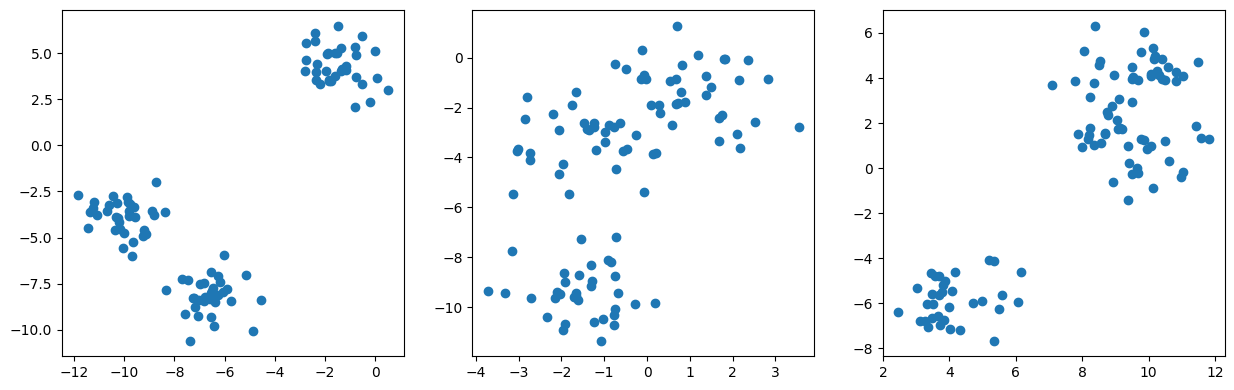

In [ ]:
from sklearn.datasets import make_blobs
import numpy as np
import time
import matplotlib.pyplot as plt
%matplotlib inline
import pylab as pl
from IPython import display
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from collections import Counter




fig, ax = plt.subplots(1, 3, figsize=(15,4.5))
#fig.figure(figsize=(30,5))
X1, y1 = make_blobs(n_samples=100, n_features=2, centers=3, random_state=1)
ax[0].scatter(X1[:,0], X1[:,1])
X2, y2 = make_blobs(n_samples=100, n_features=2, centers=3, random_state=2)
ax[1].scatter(X2[:,0], X2[:,1])
X3, y3 = make_blobs(n_samples=100, n_features=2, centers=3, random_state=4)
ax[2].scatter(X3[:,0], X3[:,1]);

Look at the above examples each containing a set of points. How many groups do you see in each case? As these examples illustrate, how many groups are there in a set of points is not always clear. Also note that our visual system is very powerful and can see instantly the groups in the given set of points. However, in a typical clustering problem there will be typically more than three features and it will not be possible to visualize the data points. To appriciate the difficuly of the problem, try to find the three groups above (on the left) when the dataset is given as a list of coordinates like below:

In [ ]:
print(X1)

[[-7.94152277e-01  2.10495117e+00]
 [-9.15155186e+00 -4.81286449e+00]
 [-1.14418263e+01 -4.45781441e+00]
 [-9.76761777e+00 -3.19133737e+00]
 [-4.53655648e+00 -8.40186288e+00]
 [-6.26302115e+00 -8.10666081e+00]
 [-6.38481234e+00 -8.47302970e+00]
 [-9.20490564e+00 -4.57687928e+00]
 [-2.76017908e+00  5.55121358e+00]
 [-1.17104176e+00  4.33091816e+00]
 [-1.00364080e+01 -5.56912090e+00]
 [-9.87589123e+00 -2.82386464e+00]
 [-7.17532921e+00 -8.77059017e+00]
 [-2.40671820e+00  6.09894447e+00]
 [-4.87418245e+00 -1.00495890e+01]
 [-6.07854700e+00 -7.93969420e+00]
 [-6.83238762e+00 -7.47067670e+00]
 [-2.34673261e+00  3.56128423e+00]
 [-1.03415662e+01 -3.90975169e+00]
 [-1.10926243e+01 -3.78396611e+00]
 [-6.50212109e+00 -7.91249101e+00]
 [-1.02639310e+01 -3.92073400e+00]
 [-6.81608302e+00 -8.44986926e+00]
 [-1.34052081e+00  4.15711949e+00]
 [-1.03729975e+01 -4.59207895e+00]
 [-7.37499896e+00 -1.05880659e+01]
 [-6.62351774e+00 -8.25338334e+00]
 [-1.35938959e+00  4.05424002e+00]
 [-1.97451969e-01  2

Moreover, there can be quite different notions of a group, as the following examples illustrate:

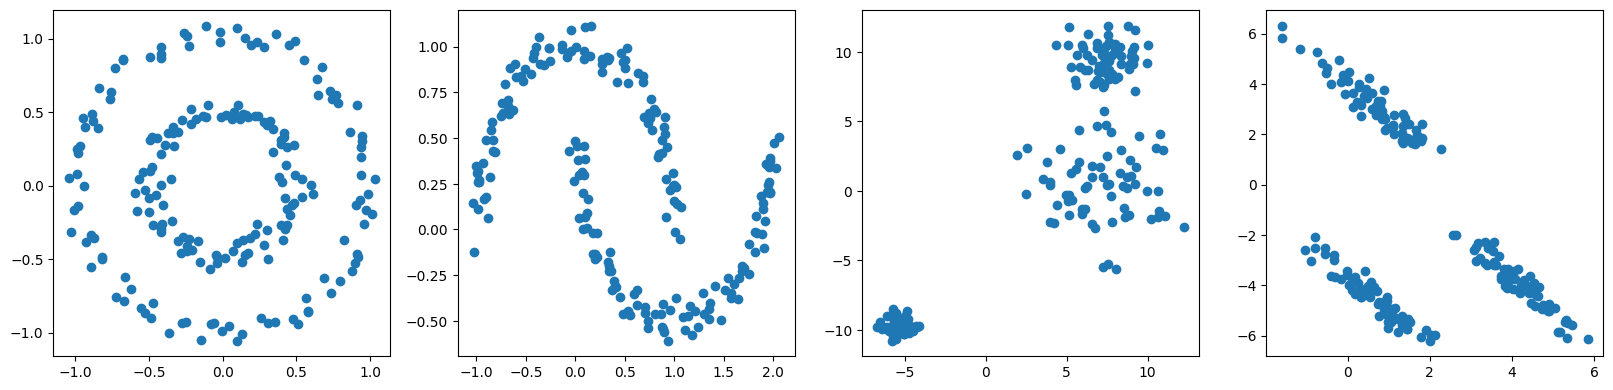

In [ ]:
from sklearn.datasets import make_circles, make_moons
fig, ax = plt.subplots(1, 4, figsize=(20,4.5))
X,y = make_circles(n_samples=200, factor=.5, noise=.05)
ax[0].scatter(X[:,0], X[:,1])
X,y = make_moons(n_samples=200, noise=.05)
ax[1].scatter(X[:,0], X[:,1])
X,y = make_blobs(n_samples=200, cluster_std=[1.0, 2.5, 0.5], random_state=8)
ax[2].scatter(X[:,0], X[:,1])
X, y = make_blobs(n_samples=200, random_state=8)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X = np.dot(X, transformation)
ax[3].scatter(X[:,0], X[:,1]);


### K-Means Clustering

#### Sum of Squared Error (SSE)

$$SSE=\sum_{i=1}^K\sum_{x \in C_i}||x-\mu_i||$$

where $x \in \mathbb{R}^n$ is a data point, $C_i$ is a cluster, $K$ is the total number of clusters, and $\mu_i$ is the mean of the points in $C_i$.


The objective of k-means clustering algorithm is to find $K$ clusters which minimizes the SSE. But it turns out that finding these clusters is an NP-hard problem. This means that nobody knows a fast (polynomial time) algorithm for the solution of this problem. Known algorithms have exponential running time which means that they are useless in practice.

K-means is a heuristic algorithm which tries to minimize SSE. Since it is heuristic, it is not guaranteed to find an optimal solutions and it often terminates in a local optimum. Below is the k-means algorithm:

    Select K objects as initial cluster centers (centroids).
    Repeat
        Assignment step: assign each object to the nearest centroid.
        Update step: update the centroids of each cluster.
    until no change occurs.
    

### K-means running time

The running time of k-means algorithm is $O(K*d*I*n)$ where
- K is the number of clusters.
- d is the dimensionality of each object.
- I is the number of iterations of the repeat loop.
- n is the number of objects.

In practice, $K$, $d$, and $I$ are relatively small numbers which makes this algorithm $O(n)$ in practice. This analysis shows that k-means is a fast algorithm which makes is suitable for clustering very large number of objects.

### Convergence of K-means

The proof of convergence of k-means is simple:
- Each step of k-means (assignment and update steps) decreases SSE.
- SSE is some positive number.
- So, in a finite number of steps the algoritm must stop.

### Examples

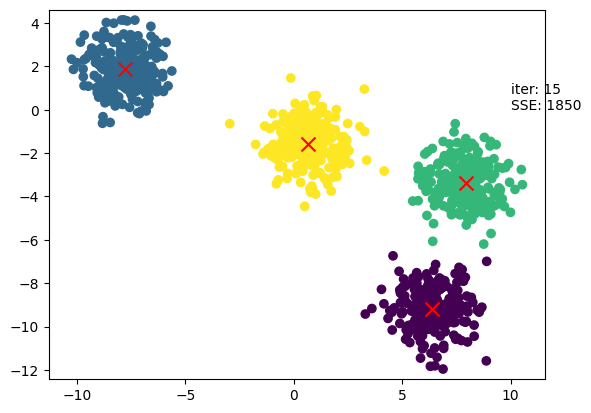

In [ ]:
# Try also random_state 6
# Try setting n_clusters different from number of centers
X, y = make_blobs(n_samples=1000, random_state=6, centers=4)
converged = False
n_clusters = 4
random_state = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=1, max_iter=1, init="random").fit(X)
prev_inertia = kmeans.inertia_
i = 2
while not converged:
    plt.clf()
    y_pred = kmeans.predict(X)
    plt.scatter(X[:, 0], X[:, 1], c=y_pred);
    plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker="x", c="r", s=100)
    plt.axis("equal")
    plt.text(10,0,"iter: {} \nSSE: {}".format(i-1, int(prev_inertia)))
    display.display(pl.gcf())
    display.clear_output(wait=True)
    time.sleep(2)
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=1, max_iter=i, init="random").fit(X)
    converged = prev_inertia == kmeans.inertia_
    prev_inertia = kmeans.inertia_
    i=i+1

In [ ]:
X[:20]

array([[ 9.60801121, -2.69148049],
       [ 1.06203323, -1.63171841],
       [-8.36711403,  0.65709059],
       [-7.86000536,  2.24556086],
       [-8.38829381,  2.00483586],
       [ 8.63983342, -3.85382244],
       [ 8.3862755 , -2.62703976],
       [ 6.60358796, -9.06154812],
       [ 6.34074984, -8.45295355],
       [ 8.8920701 , -6.99112106],
       [ 1.06531218, -1.79596945],
       [ 8.23760096, -3.58526036],
       [ 5.91892044, -8.59343244],
       [-6.51891375,  2.88879008],
       [ 8.46183193, -3.24091241],
       [-8.75475139,  1.86935855],
       [ 7.16016869, -9.16750448],
       [-0.49016372, -1.4921521 ],
       [-7.54768457,  3.00200566],
       [ 7.43540095, -3.69041572]])

We can easily get the size of each cluster and which cluster each data point is assigned.

In [ ]:
X, y = make_blobs(n_samples=100, random_state=1)
km = KMeans(n_clusters=3, random_state=1, n_init=10).fit(X)
print("Cluster Centers:")
print(km.cluster_centers_,"\n")
print("Cluster Labels of each sample:")
print(km.labels_,"\n");
print("Size of each cluster:")
print(Counter(km.labels_))

Cluster Centers:
[[-10.04935243  -3.85954095]
 [ -1.4710815    4.33721882]
 [ -6.58196786  -8.17239339]] 

Cluster Labels of each sample:
[1 0 0 0 2 2 2 0 1 1 0 0 2 1 2 2 2 1 0 0 2 0 2 1 0 2 2 1 1 2 1 1 2 1 0 2 0
 0 0 2 2 0 1 0 0 2 1 1 1 1 0 2 2 2 1 2 0 0 1 1 0 2 2 0 0 2 1 2 1 0 0 0 2 1
 1 0 2 2 1 0 1 0 0 2 1 1 1 1 0 1 2 1 1 0 0 2 2 1 2 1] 

Size of each cluster:
Counter({1: 34, 0: 33, 2: 33})


In [ ]:
km.predict(X)

array([1, 0, 0, 0, 2, 2, 2, 0, 1, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 2, 0,
       2, 1, 0, 2, 2, 1, 1, 2, 1, 1, 2, 1, 0, 2, 0, 0, 0, 2, 2, 0, 1, 0,
       0, 2, 1, 1, 1, 1, 0, 2, 2, 2, 1, 2, 0, 0, 1, 1, 0, 2, 2, 0, 0, 2,
       1, 2, 1, 0, 0, 0, 2, 1, 1, 0, 2, 2, 1, 0, 1, 0, 0, 2, 1, 1, 1, 1,
       0, 1, 2, 1, 1, 0, 0, 2, 2, 1, 2, 1], dtype=int32)

### Elbow technique
How can we decide on the right number of clusters?

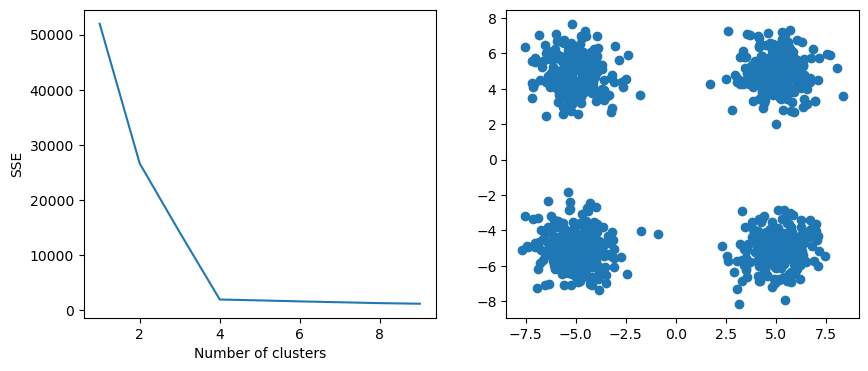

In [ ]:
centers = [(-5, -5), (-5, 5), (5, 5), (5,-5)]
X, y = make_blobs(n_samples=1000, random_state=2, centers=centers)
# Increase the number of centers and see the result
sse = {}
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, n_init=10).fit(X)
    sse[k] = kmeans.inertia_ # Inertia: This is SSE defined above
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.subplot(122)
plt.scatter(X[:, 0], X[:, 1]);

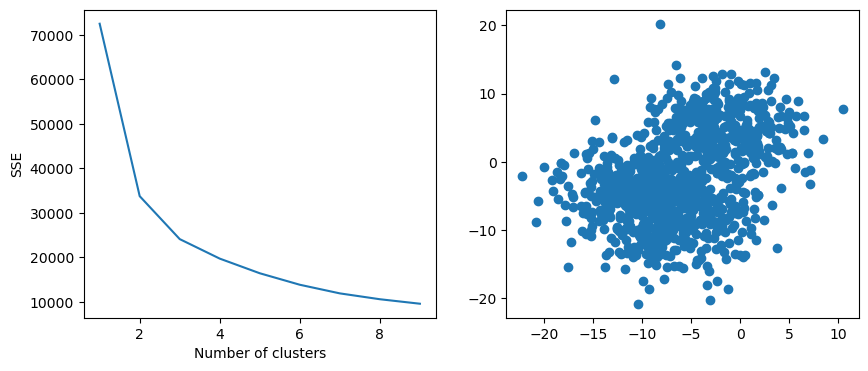

In [ ]:
# The elbow technique will not work if clusters are not well seperated.
X, y = make_blobs(n_samples=1000, random_state=1, centers=3, cluster_std=4)
# Play with centers and see the result.
sse = {}
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, n_init=10).fit(X)
    sse[k] = kmeans.inertia_ # Inertia: This is SSE defined above
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.subplot(122)
plt.scatter(X[:, 0], X[:, 1]);

### Sensitivity to initial clusters

Following is an example of a bad initialization. Note the init="random" parameter of kmeans, it forces the algorithm to choose initial centroids randomly. If you try other random_state values of kmeans you might find a good initialization.

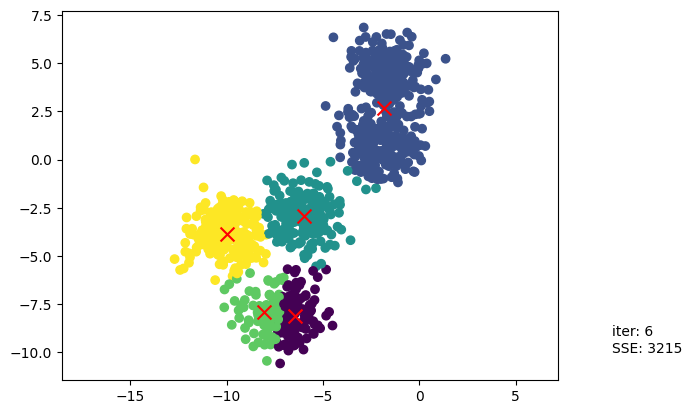

In [ ]:
X, y = make_blobs(n_samples=1000, random_state=1, centers=5)
converged = False
kmeans = KMeans(n_clusters=5, random_state=2, n_init=1, max_iter=1, init="random").fit(X)
prev_inertia = kmeans.inertia_
i = 2
while not converged:
    plt.clf()
    y_pred = kmeans.predict(X)
    plt.scatter(X[:, 0], X[:, 1], c=y_pred);
    plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker="x", c="r", s=100)
    plt.axis("equal")
    plt.text(10,-10,"iter: {} \nSSE: {}".format(i-1, int(prev_inertia)))
    display.display(pl.gcf())
    display.clear_output(wait=True)
    time.sleep(1.0)
    kmeans = KMeans(n_clusters=5, random_state=1, n_init=1, max_iter=i, init="random").fit(X)
    converged = prev_inertia == kmeans.inertia_
    prev_inertia = kmeans.inertia_
    i=i+1

### K-means++

K-means is a heuristic algorithm and is not guaranteed to find the optimal clustering with respect to SSE. It is also very sensitive to initial centroids. K-means++ is an efficient method to solve this problem.


K-means++ initialization
1. Choose the first centroid uniformly at random among the set of data points
2. For each data point $x$, compute $d(x)$, the distance of $x$ to each centroid.
3. Choose the next centroid from the data points where a point x is choosen with a probability
of $d(x)^2$
4. Repeat steps 2 and 3 until $K$ centroids are choosen.

Below example shows k-means++ in action. Note that the default initialization in sklearn's KMeans is kmeans++, so removing the init parameter is enough to choose it. Note that, for this example, even the initial centroids are choosen at just the right locations so there is little work remaining for kmeans.

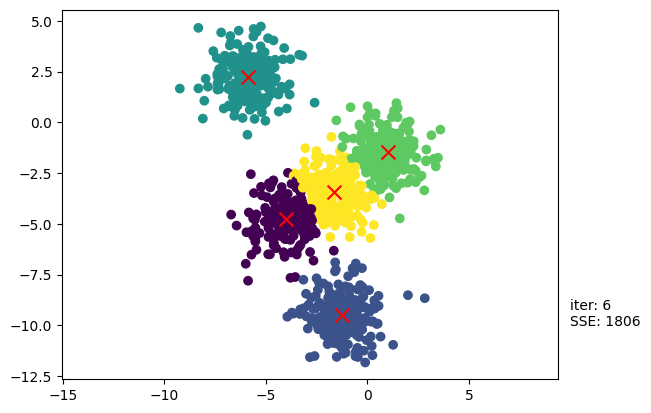

In [ ]:
X, y = make_blobs(n_samples=1000, random_state=2, centers=5)
converged = False
random_state=3
kmeans = KMeans(n_clusters=5, random_state=random_state, n_init=1, max_iter=1).fit(X)
prev_inertia = kmeans.inertia_
i = 2
while not converged:
    plt.clf()
    y_pred = kmeans.predict(X)
    plt.scatter(X[:, 0], X[:, 1], c=y_pred);
    plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker="x", c="r", s=100)
    plt.axis("equal")
    plt.text(10,-10,"iter: {} \nSSE: {}".format(i-1, int(prev_inertia)))
    display.display(pl.gcf())
    display.clear_output(wait=True)
    time.sleep(2.0)
    kmeans = KMeans(n_clusters=5, random_state=random_state, n_init=1, max_iter=i).fit(X)
    converged = prev_inertia == kmeans.inertia_
    prev_inertia = kmeans.inertia_
    i=i+1

[Empirical evaluation of the impact of k-means initialization
](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_stability_low_dim_dense.html#sphx-glr-auto-examples-cluster-plot-kmeans-stability-low-dim-dense-py)

### Bisecting K-means
A variant of k-means which can produce hierarchical clustering. It doesn't have the initialization problem.

- Start with all data points in a single cluster.
- repeat
    - Select the cluster to split. This selection can be based on the size of the cluster (largest first) or the sum of squared errors (SSE) (highest first).
    - Perform a standard k-means clustering on the selected cluster with k=2. This step can be repeated to find clusters with low SSE
    - Add the two clusters with the lowest SSE to the list of clusters
- until the total number of clusters reaches K.

[Bisecting K-Means and Regular K-Means Performance Comparison¶](https://scikit-learn.org/stable/auto_examples/cluster/plot_bisect_kmeans.html#sphx-glr-auto-examples-cluster-plot-bisect-kmeans-py)



### Disadvantages of k-means

Different sized clusters

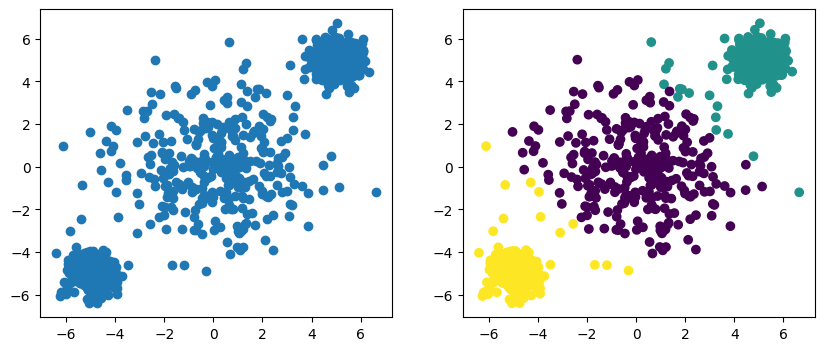

In [ ]:
centers = [(-5, -5), (0,0), (5, 5)]

X, y = make_blobs(n_samples=1000,
                                cluster_std=[0.5, 2, 0.5],
                                random_state=1, centers=centers)
y_pred = KMeans(n_clusters=3,
                random_state=1, n_init=10).fit_predict(X)
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.scatter(X[:, 0], X[:, 1])
plt.subplot(122)
plt.scatter(X[:, 0], X[:, 1], c=y_pred);

Non globalar clusters

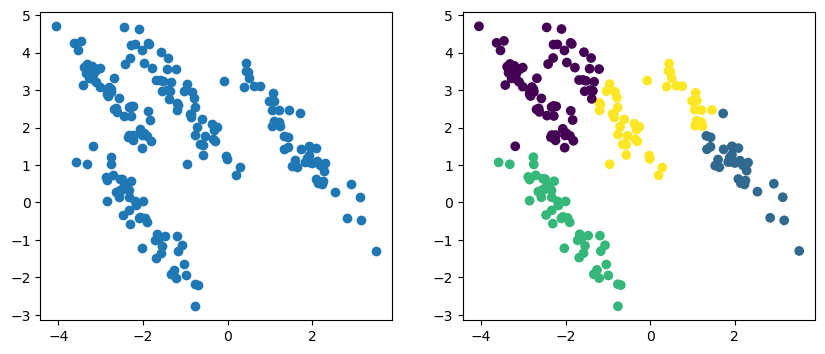

In [ ]:
from sklearn.datasets import make_circles, make_moons

X, y = make_blobs(n_samples=200, centers=4, random_state=3)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X = np.dot(X, transformation)

y_pred = KMeans(n_clusters=4,
                random_state=1, n_init="auto").fit_predict(X)
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.scatter(X[:, 0], X[:, 1])
plt.subplot(122)
plt.scatter(X[:, 0], X[:, 1], c=y_pred);

### Hierarchical clustering using AgglomerativeClustering

In [ ]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)
    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

In [ ]:
iris = load_iris()
X = iris.data

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(n_clusters=4)
model = model.fit(X)
model.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 3, 2, 3, 2, 3, 2, 3, 3, 2, 3, 2, 3, 2,
       3, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2, 0, 2, 3, 3, 3, 3, 2, 3, 2, 2, 2,
       3, 3, 3, 2, 3, 3, 3, 3, 3, 2, 3, 3, 0, 2, 0, 0, 0, 0, 3, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2])

In [ ]:
Counter(model.labels_)

Counter({np.int64(1): 50, np.int64(2): 38, np.int64(3): 26, np.int64(0): 36})

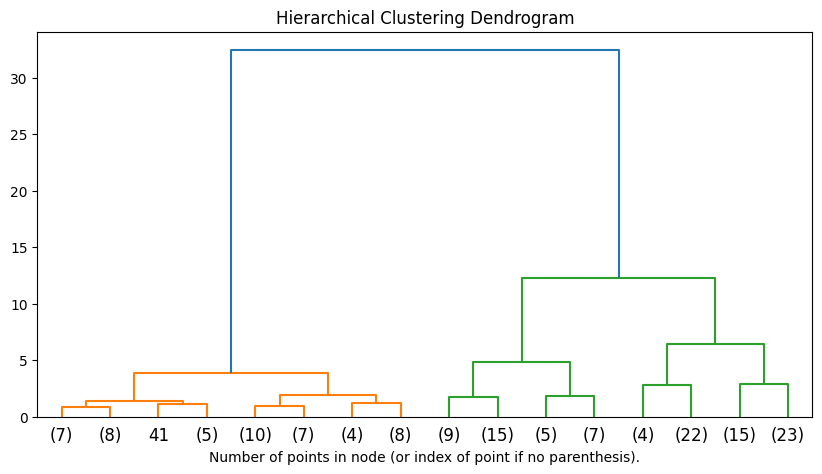

In [ ]:
iris = load_iris()
X = iris.data

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(compute_distances=True, n_clusters=3)
model = model.fit(X)
plt.figure(figsize=(10,5))
plt.title('Hierarchical Clustering Dendrogram')
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode='level', p=3)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

### DBSCAN

The example below shows that dbscan finds better clusters than kmeans for this example.

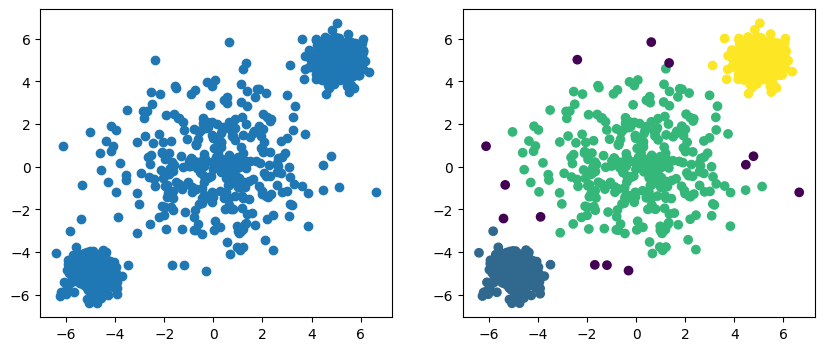

In [ ]:
centers = [(-5, -5), (0,0), (5, 5)]

X, y = make_blobs(n_samples=1000,
                                cluster_std=[0.5, 2, 0.5],
                                random_state=1, centers=centers)
y_pred = DBSCAN(eps=1, min_samples=4).fit_predict(X)
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.scatter(X[:, 0], X[:, 1])
plt.subplot(122)
plt.scatter(X[:, 0], X[:, 1], c=y_pred);

To find good values of the parameters $eps$ and $min\_samples$ the following method can be applied. The value where there is a sudden increase in the $n$ th neighborgood distance can be choosen as the $eps$ and $n$ can be chosen as the $min\_samples$. Usually a small $n$ is chosen such as 3 or 4.

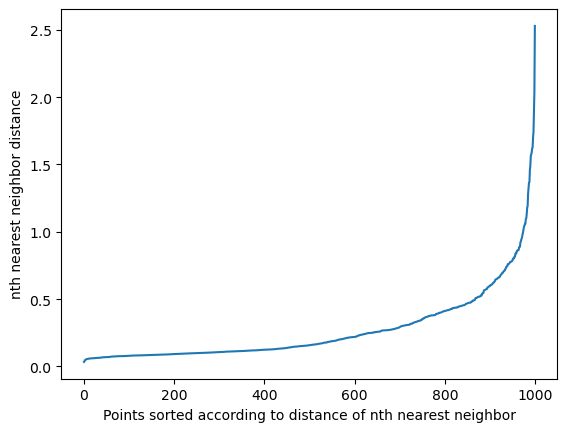

In [ ]:
nn = NearestNeighbors(n_neighbors=5)
nbrs = nn.fit(X)
distances, indices = nbrs.kneighbors(X)
distances = np.sort(distances, axis=0)
distances = distances[:,4]
plt.plot(distances)
plt.xlabel("Points sorted according to distance of nth nearest neighbor")
plt.ylabel("nth nearest neighbor distance");

A more difficult example

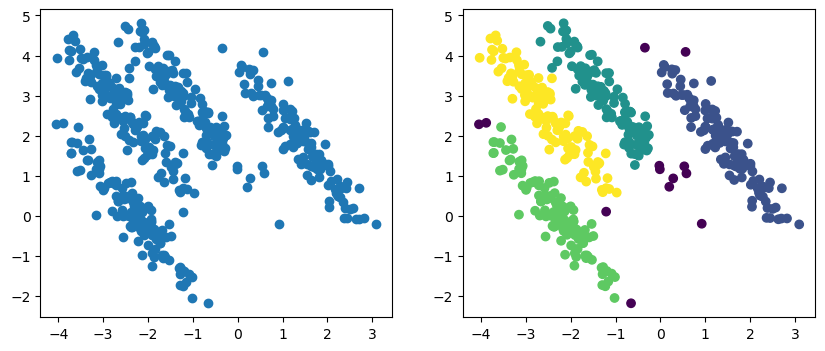

In [ ]:
X, y = make_blobs(n_samples=500, centers=4, random_state=3)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X = np.dot(X, transformation)

y_pred = DBSCAN(eps=0.4, min_samples=6).fit_predict(X)

plt.figure(figsize=(10,4))
plt.subplot(121)
plt.scatter(X[:, 0], X[:, 1])
plt.subplot(122)
plt.scatter(X[:, 0], X[:, 1], c=y_pred);

In [ ]:
nn = NearestNeighbors(n_neighbors=5)
nbrs = nn.fit(X)
distances, indices = nbrs.kneighbors(X)
distances

array([[0.        , 0.0212982 , 0.05589196, 0.10664681, 0.11568638],
       [0.        , 0.03887324, 0.14342634, 0.14409882, 0.16728293],
       [0.        , 0.29100904, 0.30141525, 0.40492506, 0.43680636],
       ...,
       [0.        , 0.09253831, 0.15693173, 0.17977941, 0.18744531],
       [0.        , 0.06240104, 0.10320511, 0.12012492, 0.20774708],
       [0.        , 0.10877575, 0.26196647, 0.28929093, 0.3279213 ]])

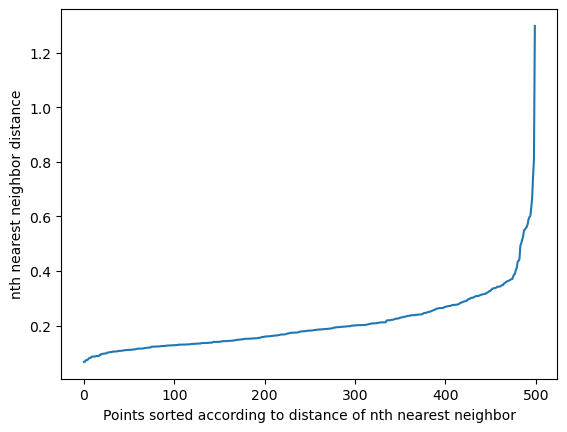

In [ ]:
nn = NearestNeighbors(n_neighbors=5)
nbrs = nn.fit(X)
distances, indices = nbrs.kneighbors(X)
distances = np.sort(distances, axis=0)
distances = distances[:,4]
plt.plot(distances)
plt.xlabel("Points sorted according to distance of nth nearest neighbor")
plt.ylabel("nth nearest neighbor distance");

# Cluster Analysis: Practice Exercises

**Exercise 1: K-Means Running Time (Calculation)**
*Question:* Suppose you are clustering a dataset of 10,000 customer records ($n=10,000$), each described by 50 features ($d=50$). You want to group them into 10 clusters ($K=10$), and the algorithm converges after 20 iterations ($I=20$). Based on the K-Means running time complexity $O(K \cdot d \cdot I \cdot n)$, estimate the number of operations. If the number of records doubles to 20,000, how does the running time change?

*Answer:*
* Number of operations $\approx 10 \times 50 \times 20 \times 10,000 = 100,000,000$.
* Because the complexity is linear with respect to $n$ ($O(n)$), if the number of data points doubles, the expected running time will also **double** (assuming the number of iterations to converge remains roughly the same).

---

**Exercise 2: Sum of Squared Error (Calculation)**
*Question:* The Sum of Squared Error (SSE) is used to evaluate the quality of a cluster. Given a single cluster with its centroid located at $\mu = (2, 2)$, and three assigned data points $x_1 = (1, 1)$, $x_2 = (2, 3)$, and $x_3 = (3, 2)$. Calculate the SSE for this cluster.

*Answer:*
The formula for SSE is $\sum ||x - \mu||^2$ (the sum of squared Euclidean distances).
* Point 1: $(1-2)^2 + (1-2)^2 = (-1)^2 + (-1)^2 = 1 + 1 = 2$
* Point 2: $(2-2)^2 + (3-2)^2 = 0^2 + 1^2 = 1$
* Point 3: $(3-2)^2 + (2-2)^2 = 1^2 + 0^2 = 1$
* **SSE** $= 2 + 1 + 1 =$ **$4$**

---

**Exercise 3: Centroid Update Step (Calculation)**
*Question:* During the update step of the K-Means algorithm, a cluster currently contains the following three 2D points: $A = (0, 5)$, $B = (2, 3)$, and $C = (4, 7)$. What will be the new coordinates of the centroid for this cluster?

*Answer:*
The new centroid is calculated as the mean of the points assigned to the cluster.
* X-coordinate: $(0 + 2 + 4) / 3 = 6 / 3 = 2$
* Y-coordinate: $(5 + 3 + 7) / 3 = 15 / 3 = 5$
* The new centroid will be at **$(2, 5)$**.

---

**Exercise 4: Algorithm Selection for Non-Globular Shapes**
*Question:* If a dataset contains two clusters shaped like intertwined half-moons (or concentric circles), which algorithm would perform better: K-Means or DBSCAN? Explain why.

*Answer:*
**DBSCAN** would perform significantly better. K-Means relies on centroids and assumes clusters are convex (globular/spherical). It will try to draw a linear boundary through the shapes. DBSCAN, however, groups points based on local density and continuous connections, allowing it to correctly identify and separate arbitrary and non-globular shapes like half-moons.

---

**Exercise 5: Interpreting the Elbow Method**
*Question:* When plotting the SSE against the number of clusters ($K$) using the Elbow technique, what general trend do you observe as $K$ increases? How do you identify the optimal $K$ from this plot, and what happens to the SSE if $K$ equals the total number of data points ($n$)?

*Answer:*
As $K$ increases, the SSE strictly **decreases** because points are closer to their respective centroids. The optimal $K$ is at the "elbow"—the point where the curve bends and the rate of SSE reduction sharply slows down (diminishing returns). If $K = n$, every data point becomes its own cluster centroid, and the **SSE becomes exactly 0**.

---

**Exercise 6: Agglomerative Hierarchical Clustering Process**
*Question:* In agglomerative (bottom-up) hierarchical clustering, if a dataset contains $N$ individual data points, how many clusters exist at the very beginning of the algorithm? If the algorithm is allowed to run to completion without any distance thresholds, how many clusters will exist at the very end?

*Answer:*
* At the very **beginning**, there are **$N$ clusters** (each data point is treated as its own individual cluster).
* At the very **end**, there will be exactly **1 cluster** that contains all $N$ data points (representing the root/top of the dendrogram).

---

**Exercise 7: K-Means Manual Iteration (Calculation)**
*Question:* Consider a 2D dataset with 4 points: $P_1 = (1, 2)$, $P_2 = (3, 3)$, $P_3 = (2, 2)$, and $P_4 = (8, 8)$. We want to partition this data into $K=2$ clusters. The initial centroids are chosen as $C_1 = (1, 1)$ and $C_2 = (7, 7)$. Perform one full iteration of the K-Means algorithm (one assignment step and one update step) using squared Euclidean distance. What are the new cluster assignments and the new coordinates of the centroids?

*Answer:*
**1. Assignment Step (Calculate squared distances to each centroid):**
*   **$P_1(1, 2)$**: Distance to $C_1 = (1-1)^2 + (2-1)^2 = 1$. Distance to $C_2 = (1-7)^2 + (2-7)^2 = 61$. $\rightarrow$ Assign to **$C_1$**
*   **$P_2(3, 3)$**: Distance to $C_1 = (3-1)^2 + (3-1)^2 = 8$. Distance to $C_2 = (3-7)^2 + (3-7)^2 = 32$. $\rightarrow$ Assign to **$C_1$**
*   **$P_3(2, 2)$**: Distance to $C_1 = (2-1)^2 + (2-1)^2 = 2$. Distance to $C_2 = (2-7)^2 + (2-7)^2 = 50$. $\rightarrow$ Assign to **$C_1$**
*   **$P_4(8, 8)$**: Distance to $C_1 = (8-1)^2 + (8-1)^2 = 98$. Distance to $C_2 = (8-7)^2 + (8-7)^2 = 2$. $\rightarrow$ Assign to **$C_2$**

**2. Update Step (Calculate new centroids as the mean of assigned points):**
*   **New $C_1$**: Mean of $P_1, P_2, P_3 = \left(\frac{1+3+2}{3}, \frac{2+3+2}{3}\right) = \left(\frac{6}{3}, \frac{7}{3}\right) \approx$ **$(2.00, 2.33)$**
*   **New $C_2$**: Mean of $P_4 = $ **$(8.00, 8.00)$**